# Model Evaluation

This is the notebook where everything comes together.

We have trained three models — Logistic Regression, Random Forest, and Gradient Boosting.
Each one was evaluated individually in its own notebook, but looking at them one by one
makes it hard to see the full picture.

Here we load all three models, compare them side by side on the same plots and metrics,
and make a final recommendation on which model works best for this credit risk problem.

## Importing Libraries

We need the same evaluation tools as before, plus a few extras for
the combined plots and the precision-recall curve.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score,roc_auc_score,classification_report,confusion_matrix,RocCurveDisplay, PrecisionRecallDisplay,precision_recall_curve,average_precision_score


## Loading the Data and Models

We load the test set and all three trained models.
The test set is the same one used in every individual notebook —
this is what makes the comparison valid.

In [ ]:
X_test  = np.load('../data/X_test_processed.npy')
y_test  = np.load('../data/y_test.npy')

lr_model = joblib.load('../models/logistic_regression.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
gb_model = joblib.load('../models/gradient_boosting.pkl')

print('Test set shape:', X_test.shape)
print('Models loaded: Logistic Regression, Random Forest, Gradient Boosting')

models = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'Gradient Boosting':   gb_model
}

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name]   = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print('Predictions generated for all models.')

Test set shape: (200, 44)
Models loaded: Logistic Regression, Random Forest, Gradient Boosting
Predictions generated for all models.


## Side-by-Side Metrics Comparison

The first thing we want is a clean summary table showing how all three models
performed on the same test set across the metrics that matter most.

We look at four numbers per model:
- **Accuracy** — overall correct predictions
- **ROC-AUC** — overall ability to rank bad applicants above good ones
- **Recall (Bad Credit)** — how many bad applicants we actually caught
- **Precision (Bad Credit)** — of those flagged, how many were truly bad

In [3]:
results = []

for name in models:
    y_pred  = predictions[name]
    y_proba = probabilities[name]

    report = classification_report(
        y_test, y_pred,
        target_names=['Good Credit', 'Bad Credit'],
        output_dict=True
    )

    results.append({
        'Model':              name,
        'Accuracy':           round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC':            round(roc_auc_score(y_test, y_proba), 4),
        'Recall (Bad)':       round(report['Bad Credit']['recall'], 4),
        'Precision (Bad)':    round(report['Bad Credit']['precision'], 4),
        'F1 (Bad)':           round(report['Bad Credit']['f1-score'], 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Accuracy  ROC-AUC  Recall (Bad)  Precision (Bad)  F1 (Bad)
Model                                                                          
Logistic Regression     0.725   0.7823        0.7667           0.5287    0.6259
Random Forest           0.735   0.7920        0.6667           0.5479    0.6015
Gradient Boosting       0.720   0.7810        0.7167           0.5244    0.6056


Looking at the full picture, the three models perform surprisingly close to each other — no single model dominates everything.

Random Forest wins on ROC-AUC (0.792) — meaning it is the best overall at ranking bad applicants above good ones across all possible thresholds. It also has the highest accuracy (73.5%) and the best precision for bad credit (0.548) — when it flags someone as a bad applicant, it is right more often than the other two.

Logistic Regression wins on recall (0.767) — it catches the most bad applicants out of the three. For a bank, this is arguably the most important metric since missing a bad applicant means approving a loan that will default.

Gradient Boosting is in the middle on everything — it never wins a metric outright, which on a dataset of only 1000 samples is expected. The extra complexity did not pay off here.

The honest conclusion is that all three models are very competitive on this dataset, with differences of less than 1% on most metrics. Random Forest is the recommended choice — it has the best ROC-AUC and precision while still catching 67% of bad applicants, making it the most balanced option overall.

## ROC Curves — All Three Models on the Same Plot

Plotting all three ROC curves together is the clearest way to see
which model does a better job of separating good from bad applicants.
The further a curve is toward the top-left corner, the better.

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


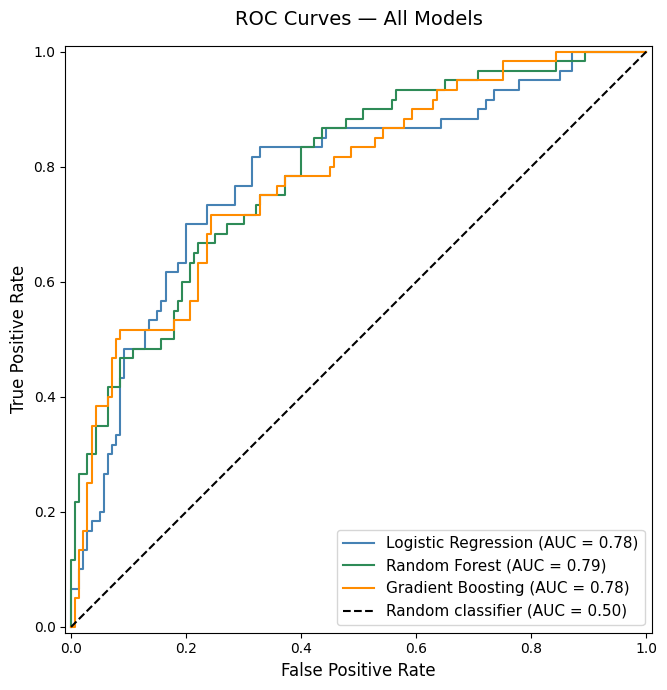

In [10]:
colors = {
    'Logistic Regression': 'steelblue',
    'Random Forest':       'seagreen',
    'Gradient Boosting':   'darkorange'
}

fig, ax = plt.subplots(figsize=(9, 7))

for name in models:
    RocCurveDisplay.from_predictions( y_test, probabilities[name], name=name,color=colors[name], ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.50)')
ax.set_title('ROC Curves — All Models', fontsize=14, pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

All three curves sit well above the diagonal, which confirms that all three models are genuinely useful — none of them is close to random guessing.

Random Forest (green) has a slight edge with AUC 0.79, staying consistently above the other two curves especially in the early left region where false positive rates are low. This is the most valuable part of the curve for a bank — it means Random Forest catches more bad applicants before generating too many false alarms.
What is interesting is how close the three curves are throughout the plot — they overlap frequently and cross each other multiple times. This visually confirms what the metrics table told us: the differences between the models are real but very small on this dataset.

All three are significantly better than the random baseline, which is the most important takeaway — we have built three models that genuinely learned something meaningful about credit risk.

## Precision-Recall Curves

The ROC curve is great for overall comparison, but on imbalanced datasets
the **Precision-Recall curve** gives additional insight.

It shows the tradeoff between:
- **Precision** — of everyone we flag as bad credit, how many actually are?
- **Recall** — of all actual bad credit applicants, how many do we catch?

A model that pushes this curve toward the top-right corner achieves high precision
and high recall at the same time — the ideal but rarely achieved outcome.
The **Average Precision (AP)** score summarises the curve into one number,
similar to how AUC summarises the ROC curve.

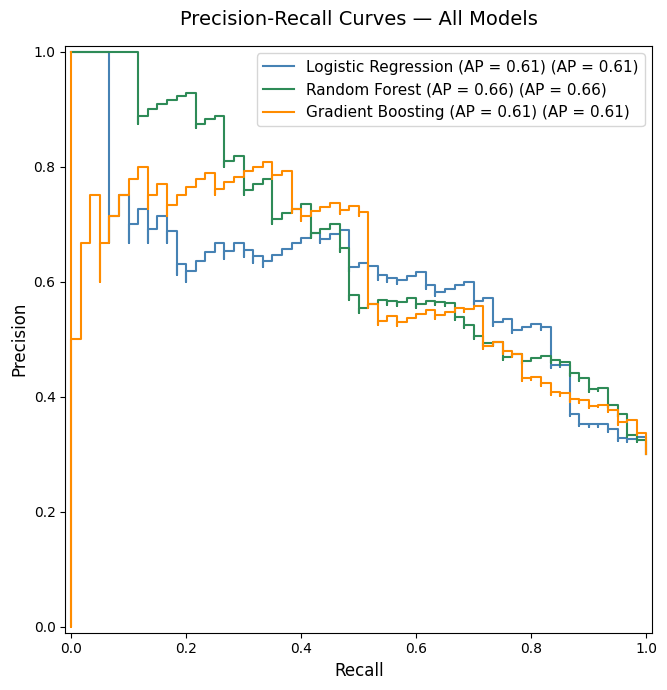

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

for name in models:
    ap = average_precision_score(y_test, probabilities[name])
    PrecisionRecallDisplay.from_predictions( y_test, probabilities[name], name=f'{name} (AP = {ap:.2f})', color=colors[name], ax=ax)

ax.set_title('Precision-Recall Curves — All Models', fontsize=14, pad=15)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Random Forest (green) clearly stands out here with an Average Precision of 0.66, compared to 0.61 for both Logistic Regression and Gradient Boosting. This gap is more visible here than in the ROC curve and confirms that Random Forest handles the class imbalance better than the other two.

Looking at the curve shapes, Random Forest stays higher across most recall values — meaning when we push the model to catch more bad applicants, it maintains better precision for longer before it starts generating too many false alarms. This is exactly the behaviour you want in credit risk.

At high recall values (above 0.6), all three curves converge and become very similar — at that point all models are flagging almost everyone as bad credit, so precision naturally drops for all of them equally.

The gap between Random Forest and the other two being most visible in the precision-recall space rather than the ROC space makes sense — precision-recall curves are more sensitive to how well a model handles the minority class, which is exactly what we care about here.

## Confusion Matrices — Side by Side

Plotting all three confusion matrices next to each other makes it easy
to compare exactly where each model made its mistakes.
We focus on the bottom-left cell — the False Negatives —
bad applicants that slipped through as the most costly error.

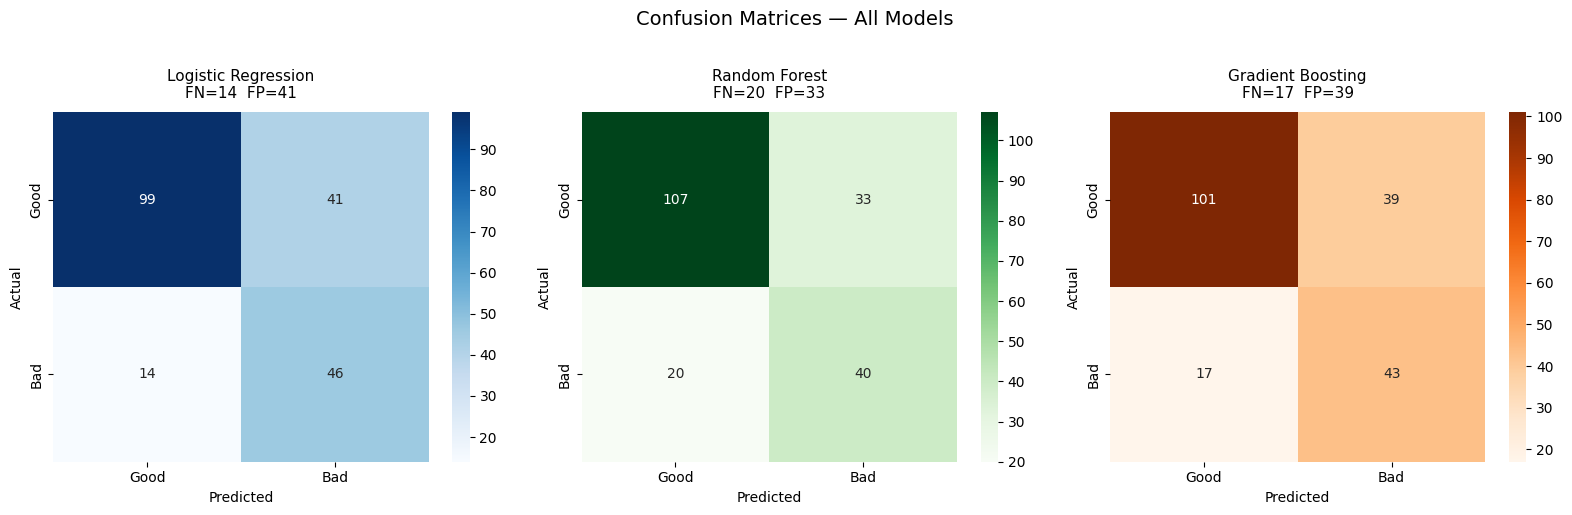

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = {
    'Logistic Regression': 'Blues',
    'Random Forest':       'Greens',
    'Gradient Boosting':   'Oranges'
}

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap( cm,  annot=True, fmt='d',cmap=cmaps[name], xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'], ax=ax )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nFN={fn}  FP={fp}', fontsize=11, pad=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Looking at all three side by side makes the tradeoffs very clear.

Logistic Regression missed the fewest bad applicants with only 14 False Negatives — but paid for it with the most false alarms, wrongly rejecting 41 good customers. It is the most aggressive at catching bad applicants.

Random Forest flipped that tradeoff — it has the fewest false alarms with only 33 False Positives, meaning it is the fairest to good customers. But it missed the most bad applicants with 20 False Negatives.

Gradient Boosting sits exactly in the middle on both counts — 17 missed bad applicants and 39 wrongly rejected good ones.

The choice between these models ultimately comes down to what the bank cares about more. If the priority is catching as many bad applicants as possible, Logistic Regression wins. If the priority is being fair to good customers while still maintaining solid detection, Random Forest is the better choice. Given that Random Forest also had the best ROC-AUC and Average Precision, it remains our recommended model overall.

## Visual Metrics Comparison

A bar chart makes it easy to see at a glance how each model performed
across all four key metrics.

/tmp/ipykernel_49130/3001761282.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [n.replace(' ', '\n') for n in model_names], fontsize=9
/tmp/ipykernel_49130/3001761282.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [n.replace(' ', '\n') for n in model_names], fontsize=9
/tmp/ipykernel_49130/3001761282.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [n.replace(' ', '\n') for n in model_names], fontsize=9
/tmp/ipykernel_49130/3001761282.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [n.replace(' ', '\n') for n in model_names], fontsize=9


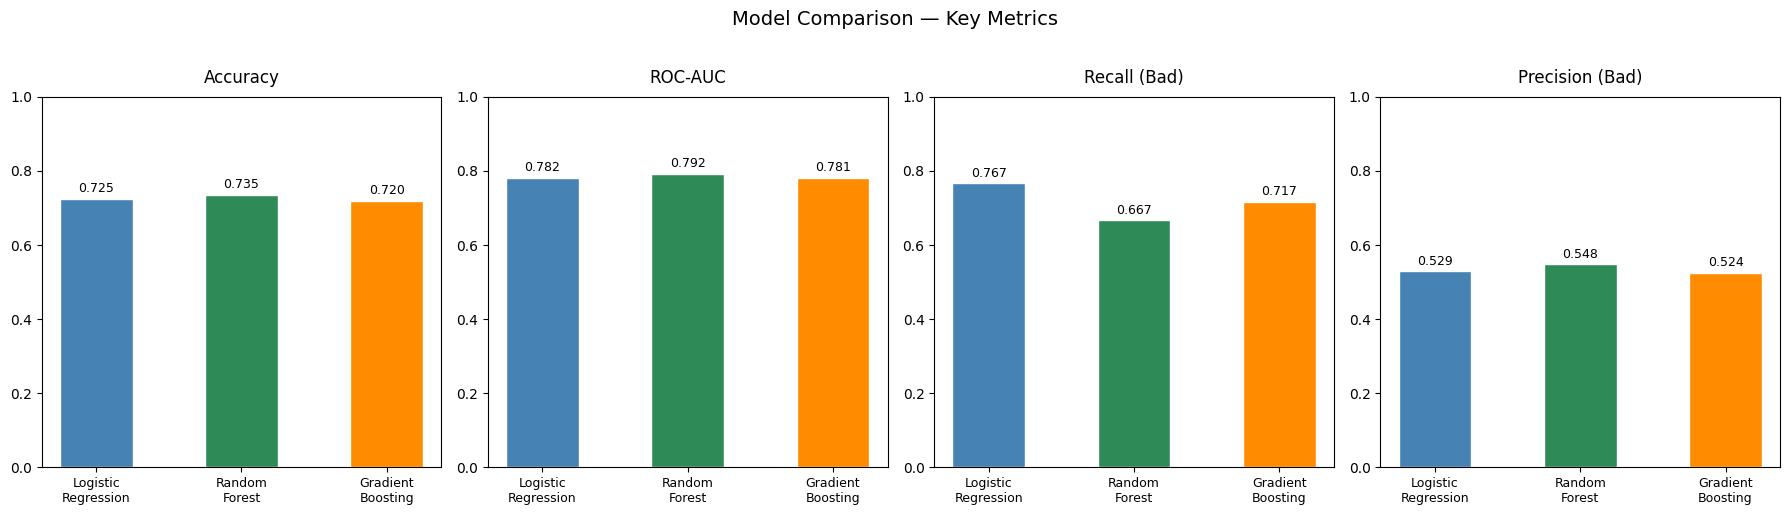

In [12]:
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'Recall (Bad)', 'Precision (Bad)']
model_names     = results_df.index.tolist()
bar_colors      = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].values
    bars = ax.bar(model_names, values, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=12, pad=10)
    ax.set_ylim(0, 1)
    ax.set_xticklabels( [n.replace(' ', '\n') for n in model_names], fontsize=9
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Model Comparison — Key Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

In this notebook we brought all three models together and compared them
on the same test set using the same metrics.

The key results across all models were:

- Logistic Regression — ROC-AUC 0.78, caught 77% of bad applicants,
  strong baseline for a linear model
- Random Forest — ROC-AUC 0.79, best overall AUC, fewer false alarms
  but missed more bad applicants than Logistic Regression
- Gradient Boosting — ROC-AUC 0.78, middle ground on all metrics,
  showed signs of mild overfitting on this dataset size

The consistent finding across all three models is that **`credit_amount`,
`duration_months`, and `checking_account_status`** are the strongest
predictors of credit default risk — a result confirmed independently
by three completely different algorithms.

The next notebook covers **model interpretation** — going deeper into
understanding why the models make the predictions they do.